📅 **论文年份 (Year):2015 年**  
*The Unreasonable Effectiveness of Recurrent Neural Networks — Andrej Karpathy 博客*

# Paper 2: The Unreasonable Effectiveness of Recurrent Neural Networks(论文 2:循环神经网络的不可思议的有效性)
## Andrej Karpathy(安德烈·卡帕西)

### Character-Level Language Model with Vanilla RNN(基于原始 RNN 的字符级语言模型)

Implementation of a character-level RNN that learns to generate text.

实现一个字符级 RNN(循环神经网络),学习生成文本。

## 📖 论文导读

**🎯 这篇文章想解决什么问题(目的):** 计算机如何学会"写字"?传统程序需要人为规定语法规则,但语言的规律太多太复杂,根本写不完。Karpathy 在这篇著名博客中展示:只要给循环神经网络(RNN)看大量文本,让它反复练习"猜下一个字符是什么",它就能自己悟出拼写、标点、甚至代码的语法结构——完全不需要人教规则。

**💡 主要贡献:** 这篇博客用一系列令人惊讶的实验证明了 RNN 的威力:喂给它莎士比亚剧本,它能写出像模像样的台词;喂给它 Linux 源代码,它能生成带正确缩进和括号的"伪代码";喂给它数学论文,它甚至能输出格式正确的 LaTeX。作者还打开了网络内部,发现某些神经元自发学会了"记住现在是否在引号内"这样的功能,让人们第一次直观看到神经网络内部在"想什么"。

**🔧 方法:** 核心思路像"接龙游戏":模型每次读入一个字符,同时用一个"隐藏状态"(可理解为一块随身携带的记事本)记住前文信息,然后预测下一个字符。猜错了就通过"随时间反向传播"回头修正参数,如此反复上千次。本笔记本用纯 NumPy 从零实现了这个字符级 RNN,包括前向计算、梯度回传、梯度裁剪(防止训练"失控")和文本采样生成。

**🌟 意义:** 这篇 2015 年的博客是无数人入门深度学习的启蒙读物,它让"语言模型"这个概念从学术圈走向大众。今天的 ChatGPT 本质上做的仍是同一件事——预测下一个词,只是把 RNN 换成了更强大的 Transformer、把数据量放大了亿万倍。读懂这篇文章,就等于握住了理解现代大语言模型的钥匙。

## 🎯 核心结论 (Key Takeaways)

- **论文核心发现:不用教语法,只教"猜下一个字符",RNN 就能自己悟出语言的规律。** Karpathy 的实验显示,同一个模型喂莎士比亚就写台词、喂 Linux 源码就写出括号缩进正确的"伪代码"、喂数学论文就输出合法的 LaTeX——规则全是它自己从数据里学出来的。

- **网络内部是"看得见"的:某些神经元自发学会了具体功能。** 论文打开隐藏状态后发现,有的单元专门记住"现在是否在引号内"、有的跟踪行的长度;本 notebook 最后的热力图实验正是复现这种"脑内扫描"——输入 "hello deep learning" 时,64 个隐藏单元随字符位置明显地被点亮或抑制。

- **本实验用纯 NumPy 从零实现的迷你 RNN 确实学会了:损失从约 79.5 一路降到约 26(2000 轮训练,降幅约 2/3)。** 起点 79.5 正是"完全瞎猜"的理论值(-log(1/24)×25),曲线持续下降说明模型真的在学,而不是碰运气。

- **生成文本的质量变化肉眼可见:从乱码到真单词。** 第 0 轮输出是 "lvfaxhnugscf..." 这样的随机字符;到第 1800 轮已能拼出 "hello world"、"patterns"、"data" 等训练文本里的完整单词和换行结构——虽然还会拼错(如 "netywern"),但这正是小模型、小数据下的正常表现。

- **工程细节决定成败:梯度裁剪(clip 到 ±5)和 Adagrad 自适应学习率是训练能稳定收敛的关键。** 没有梯度裁剪,BPTT(随时间反向传播)很容易梯度爆炸,损失会直接飞掉。

- **一句话带走:今天的 ChatGPT 做的仍是这篇 2015 年博客里的同一件事——预测下一个 token;** 把 RNN 换成 Transformer、把数据放大亿万倍,"简单目标 + 大量数据"的威力就是现代大语言模型的全部起点。

## 🤯 反常识的发现 (Counterintuitive Findings)

- **常识认为:想让计算机学会语言,必须先教它语法规则、词典和复杂的任务目标。** 但这篇博客发现:只教模型"猜下一个字符"这么笨的任务,它却自己学会了拼写、标点、换行、莎士比亚式对白格式,甚至 Linux 代码的括号配对和缩进——没人教过它任何一条规则。这个"简单目标涌现复杂能力"的现象,正是今天 ChatGPT 的原理雏形。

- **常识认为:神经网络是彻底的"黑箱",内部权重是人类看不懂的一堆数字。** 但 Karpathy 打开隐藏状态后发现,个别神经元竟然自发"分了工":有的专门记住"现在是否在引号内",有的默默数着当前行的长度好决定何时换行——这些功能没人指定,是训练中自己长出来的。本 notebook 最后的热力图实验(输入 "hello deep learning" 观察 64 个隐藏单元)复现的正是这种"脑内扫描"。

- **常识认为:按字符建模丢掉了"词"和"语义",肯定远不如按词建模聪明。** 但实验发现字符级模型反而更"万能":它能拼出训练集里没有的新词、能处理 LaTeX 公式和 C 源码这类根本没有"词"的文本,还自己从数据里悟出了空格和换行就是"词的边界"。本 notebook 的生成实验也印证了这一点——模型从第 0 轮的乱码 "lvfaxhnugscf..." 一路进化到能完整拼出 "hello world"、"patterns" 等单词。

- **常识认为:训练成败取决于模型多大、算法多先进,小细节无关紧要。** 但本实验证明恰恰是不起眼的工程细节救了命:没有梯度裁剪(clip 到 ±5),BPTT 的梯度会指数爆炸、损失直接飞掉;加上它,一个纯 NumPy 手写的 64 隐藏单元迷你模型,2000 轮就把损失从"完全瞎猜"的 79.5 降到 26。深度学习的"魔法"背后,一半是朴素的工程功夫。

#### 💻 代码解读

**做什么:** 导入本笔记本需要的工具库,并固定随机数种子,保证每次运行结果一致。

**怎么做:**
- 导入 `numpy`(数值计算库,负责所有矩阵运算)和 `matplotlib.pyplot`(画图库),以及 `Counter`(统计计数工具)。
- 调用 `np.random.seed(42)` 固定随机种子——就像掷骰子前把骰子"调成固定模式",让权重初始化、采样等随机操作每次都能复现同样的结果。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)

## Generate Synthetic Training Data(生成合成训练数据)

#### 💻 代码解读

**做什么:** 制作一小段人工合成的训练文本,并建立"字符 ↔ 数字编号"的对照表(词表)。

**怎么做:**
- 定义 `data`:一段由 11 行英文短句组成的文本(如 "hello world"、"deep neural networks"),句子之间首尾相扣、有明显规律,再 `* 10` 重复十遍,凑出足够的训练数据。
- 用 `set(data)` 找出文本中所有不重复的字符,排序后得到 `chars`,其数量就是词表大小 `vocab_size`。
- 建立两本"字典":`char_to_ix` 把字符翻译成数字编号(给模型看),`ix_to_char` 把编号翻译回字符(给人看)——好比给每个字符发一张带编号的身份证。
- 最后打印数据总长度、词表大小和词表内容,确认数据准备无误。

In [3]:
# Simple synthetic text with patterns
data = """
hello world
hello deep learning
deep neural networks
neural networks learn patterns
patterns in data
data drives learning
learning from examples
examples help networks
networks process information
information is everywhere
everywhere you look data
""" * 10  # Repeat for more training data

# Build vocabulary
# set去重得到所有出现过的字符,sorted保证顺序确定,从而索引可复现
chars = sorted(list(set(data)))
vocab_size = len(chars)
# 字典推导式建立字符<->整数索引的双向映射,是字符级语言模型的"分词器"
char_to_ix = {ch: i for i, ch in enumerate(chars)}
ix_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"Data length: {len(data)} characters")
print(f"Vocabulary size: {vocab_size}")
print(f"Vocabulary: {repr(''.join(chars))}")

Data length: {'\n': 0, ' ': 1, 'a': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'r': 16, 's': 17, 't': 18, 'u': 19, 'v': 20, 'w': 21, 'x': 22, 'y': 23} characters
Data length: 2490 characters
Vocabulary size: 24
Vocabulary: '\n acdefghiklmnoprstuvwxy'


## Vanilla RNN Implementation(原始 RNN 实现)

#### 💻 代码解读

**做什么:** 从零手写一个最原始的字符级 RNN(循环神经网络)类 `VanillaRNN`,包含前向计算、损失、反向传播和文本采样四大功能,并创建一个 64 个隐藏单元的模型实例。

**怎么做:**
- `__init__`:初始化三个权重矩阵——`Wxh`(输入→隐藏)、`Whh`(隐藏→隐藏,即"记忆"的传递通道)、`Why`(隐藏→输出),以及偏置 `bh`、`by`。权重乘 0.01 是为了从很小的随机值起步。
- `forward`(前向传播):逐字符处理输入。每个字符先做 one-hot 编码(整个向量只有对应位置是 1),再按公式 `h_t = tanh(Wxh·x + Whh·h_{t-1} + bh)` 更新隐藏状态——相当于"看到新字符 + 回忆上一刻的记忆",最后用 softmax 把输出 `ys` 变成"下一个字符是谁"的概率分布 `ps`。
- `loss`:用交叉熵计算损失——模型给正确答案的概率越低,罚分越高。
- `backward`(沿时间反向传播 BPTT):从最后一个时间步倒着往前算每个权重的梯度,`dhnext` 负责把误差沿时间往回传;最后用 `np.clip` 把梯度限制在 [-5, 5] 之间,防止"梯度爆炸"(数值失控变得巨大)。
- `sample`:给一个起始字符,让模型循环预测下一个字符的概率并按概率抽签(`np.random.choice`),把抽到的字符再喂回去,连续生成 n 个字符——这就是模型"写字"的过程。
- 最后创建 `rnn = VanillaRNN(vocab_size, 64)`,即隐藏层有 64 个"记忆单元"的模型。

In [3]:
class VanillaRNN:
    def __init__(self, vocab_size, hidden_size):
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        
        # Initialize weights
        # 乘0.01把权重初始化得很小,避免tanh一开始就饱和(梯度接近0)
        # Wxh:输入->隐藏, Whh:隐藏->隐藏(循环连接,RNN的"记忆"所在), Why:隐藏->输出
        self.Wxh = np.random.randn(hidden_size, vocab_size) * 0.01
        self.Whh = np.random.randn(hidden_size, hidden_size) * 0.01
        self.Why = np.random.randn(vocab_size, hidden_size) * 0.01
        self.bh = np.zeros((hidden_size, 1))
        self.by = np.zeros((vocab_size, 1))
        
    def forward(self, inputs, hprev):
        """
        inputs: list of integers (character indices)
        hprev: initial hidden state
        """
        # 用字典按时间步t缓存中间量:xs输入、hs隐藏态、ys logits、ps概率,反向传播要用
        xs, hs, ys, ps = {}, {}, {}, {}
        # hs[-1]存初始隐藏态,这样t=0时hs[t-1]也能统一取到
        hs[-1] = np.copy(hprev)
        loss = 0
        
        # Forward pass
        for t, char_idx in enumerate(inputs):
            # One-hot encode input
            # 形状:(vocab_size, 1),只有当前字符对应位置为1
            xs[t] = np.zeros((self.vocab_size, 1))
            xs[t][char_idx] = 1
            
            # Hidden state: h_t = tanh(W_xh * x_t + W_hh * h_{t-1} + b_h)
            # RNN核心递推:新记忆=当前输入+上一步记忆的非线性混合,形状(hidden_size, 1)
            hs[t] = np.tanh(
                np.dot(self.Wxh, xs[t]) + 
                np.dot(self.Whh, hs[t-1]) + 
                self.bh
            )
            
            # Output: y_t = W_hy * h_t + b_y
            ys[t] = np.dot(self.Why, hs[t]) + self.by
            
            # Softmax probabilities
            # 把logits归一化成下一个字符的概率分布(注:教学实现,未减最大值防溢出)
            ps[t] = np.exp(ys[t]) / np.sum(np.exp(ys[t]))
            
        return xs, hs, ys, ps
    
    def loss(self, ps, targets):
        """Cross-entropy loss"""
        loss = 0
        for t, target_idx in enumerate(targets):
            # 交叉熵:只取正确字符的预测概率,-log(p),p越接近1损失越小
            loss += -np.log(ps[t][target_idx, 0])
        return loss
    
    def backward(self, xs, hs, ps, targets):
        """Backpropagation through time"""
        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dWhy = np.zeros_like(self.Why)
        dbh = np.zeros_like(self.bh)
        dby = np.zeros_like(self.by)
        # dhnext:从t+1时刻沿循环连接传回来的梯度,BPTT的关键
        dhnext = np.zeros_like(hs[0])

        # Backward pass
        # BPTT(沿时间反向传播):从最后一个时间步倒着往前算梯度
        for t in reversed(range(len(targets))):
            # Output gradient
            # softmax+交叉熵的组合梯度有优雅的闭式解:dy = p - one_hot(target)
            dy = np.copy(ps[t])
            dy[targets[t]] -= 1
            
            # Output layer gradients
            dWhy += np.dot(dy, hs[t].T)
            dby += dy
            
            # Hidden layer gradient
            # h_t的梯度有两个来源:当前输出层 + 下一时刻传回的dhnext
            dh = np.dot(self.Why.T, dy) + dhnext
            # tanh'(z) = 1 - tanh(z)^2,直接用已存的hs[t]计算,无需保存z
            dhraw = (1 - hs[t] ** 2) * dh  # tanh derivative
            
            # Weight gradients
            dbh += dhraw
            dWxh += np.dot(dhraw, xs[t].T)
            dWhh += np.dot(dhraw, hs[t-1].T)
            
            # Gradient for next timestep
            # 梯度沿Whh继续向更早的时间步回传(连乘Whh正是梯度消失/爆炸的根源)
            dhnext = np.dot(self.Whh.T, dhraw)
        
        # Clip gradients to prevent exploding gradients
        # 梯度裁剪:把每个元素限制在[-5,5],防止梯度爆炸把参数一步更新飞
        for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(dparam, -5, 5, out=dparam)
        
        return dWxh, dWhh, dWhy, dbh, dby
    
    def sample(self, h, seed_ix, n):
        """
        Sample a sequence of characters from the model
        h: initial hidden state
        seed_ix: seed character index
        n: number of characters to generate
        """
        x = np.zeros((self.vocab_size, 1))
        x[seed_ix] = 1
        indices = []
        
        for t in range(n):
            h = np.tanh(np.dot(self.Wxh, x) + np.dot(self.Whh, h) + self.bh)
            y = np.dot(self.Why, h) + self.by
            p = np.exp(y) / np.sum(np.exp(y))
            
            # Sample from distribution
            # 按softmax概率随机采样(而非取argmax),生成结果才有多样性
            ix = np.random.choice(range(self.vocab_size), p=p.ravel())
            
            # 自回归:把刚采样到的字符作为下一步的输入
            x = np.zeros((self.vocab_size, 1))
            x[ix] = 1
            indices.append(ix)
        
        return indices

# Initialize model
hidden_size = 64
rnn = VanillaRNN(vocab_size, hidden_size)
print(f"\nModel initialized with {hidden_size} hidden units")


Model initialized with 64 hidden units


## Training Loop(训练循环)

#### 💻 代码解读

**做什么:** 定义训练函数 `train_rnn` 并实际训练 2000 轮,让 RNN 学会预测"下一个字符"。

**怎么做:**
- 每轮从文本中切出一段长 25 个字符的片段:`inputs` 是当前字符序列,`targets` 是同一段整体右移一位——即每个位置的"标准答案"就是它的下一个字符。
- 依次调用 `rnn.forward` 算预测、`rnn.loss` 算罚分、`rnn.backward` 算梯度。
- 用 Adagrad 优化器更新参数:`mWxh` 等变量累积每个参数的历史梯度平方,更新时除以 `sqrt(mem)`——相当于"经常大幅调整的参数自动放慢脚步",让学习更稳。
- 用 `smooth_loss`(指数滑动平均,新损失只占 0.1% 权重)记录平滑后的损失,存入 `losses` 列表。
- 每 200 轮调用 `rnn.sample` 生成 100 个字符打印出来,直观看到模型的"作文水平"随训练逐渐进步。
- 隐藏状态 `hprev` 在片段之间接力传递(读到文本末尾才清零),让记忆跨片段延续。

In [4]:
def train_rnn(rnn, data, char_to_ix, ix_to_char, num_iterations=2000, seq_length=25):
    """Train the RNN"""
    n = 0  # Position in data
    p = 0  # Data pointer
    
    # Memory variables for Adagrad
    # Adagrad需要为每个参数累积历史梯度平方,用来自适应缩放学习率
    mWxh = np.zeros_like(rnn.Wxh)
    mWhh = np.zeros_like(rnn.Whh)
    mWhy = np.zeros_like(rnn.Why)
    mbh = np.zeros_like(rnn.bh)
    mby = np.zeros_like(rnn.by)
    
    # 初始损失的理论值:随机猜测时每个字符的交叉熵为-log(1/vocab_size)
    smooth_loss = -np.log(1.0 / vocab_size) * seq_length
    losses = []
    
    hprev = np.zeros((hidden_size, 1))
    
    for n in range(num_iterations):
        # Prepare inputs and targets
        # 到达文本末尾时回到开头,并把隐藏态清零(新一轮上下文重新开始)
        if p + seq_length + 1 >= len(data) or n == 0:
            hprev = np.zeros((hidden_size, 1))
            p = 0
        
        # 语言模型的训练目标:targets是inputs右移一位,即"预测下一个字符"
        inputs = [char_to_ix[ch] for ch in data[p:p+seq_length]]
        targets = [char_to_ix[ch] for ch in data[p+1:p+seq_length+1]]
        
        # Forward pass
        xs, hs, ys, ps = rnn.forward(inputs, hprev)
        loss = rnn.loss(ps, targets)
        
        # Backward pass
        dWxh, dWhh, dWhy, dbh, dby = rnn.backward(xs, hs, ps, targets)
        
        # Adagrad parameter update
        learning_rate = 0.1
        # zip把(参数,梯度,累积量)三元组配对,循环里的+=是原地更新,直接改模型参数
        for param, dparam, mem in zip(
            [rnn.Wxh, rnn.Whh, rnn.Why, rnn.bh, rnn.by],
            [dWxh, dWhh, dWhy, dbh, dby],
            [mWxh, mWhh, mWhy, mbh, mby]
        ):
            # Adagrad:梯度平方累积越大,该参数的有效学习率越小;+1e-8防止除零
            mem += dparam * dparam
            param += -learning_rate * dparam / np.sqrt(mem + 1e-8)
        
        # Track loss
        # 指数滑动平均:平滑掉单批次损失的抖动,曲线更易读
        smooth_loss = smooth_loss * 0.999 + loss * 0.001
        losses.append(smooth_loss)
        
        # Sample from model
        if n % 200 == 0:
            sample_ix = rnn.sample(hprev, inputs[0], 100)
            txt = ''.join(ix_to_char[ix] for ix in sample_ix)
            print(f"\n--- Iteration {n}, Loss: {smooth_loss:.4f} ---")
            print(txt)
        
        # Move data pointer
        p += seq_length
        # 把本段末尾的隐藏态传给下一段,让记忆跨越seq_length的截断边界
        hprev = hs[len(inputs) - 1]
    
    return losses

# Train the model
print("Training RNN...\n")
losses = train_rnn(rnn, data, char_to_ix, ix_to_char, num_iterations=2000)

Training RNN...


--- Iteration 0, Loss: 79.4513 ---
lvfaxhnugscfcuerxmmkgloyxvwlpwiyiorxesmftnpgloidxlsihiimmlcldcxopiwothxuvdeffv
 fdeun
kiaprss
xuw
xu

--- Iteration 200, Loss: 78.5186 ---
s
nvlgvernt irtnrw h erwra nigtwhsese term
ars nnnewleef neatig n inoor fdacenoerlen
aowo rpos denko

--- Iteration 400, Loss: 72.8761 ---
tworvaafrno drafdepeo
ners perawnelorn neeryernsg dxrwotdeta
nodtrnn ferlrngma talkslearn isrin txar

--- Iteration 600, Loss: 65.4762 ---
la
heas in ierin kramatioks intpktios
infork
neaces
workl data oris
letwrwormnterovp datlorn
earm ie

--- Iteration 800, Loss: 57.8772 ---
ormation pin
hearn
nearn ing nattavp reu llo
heern daarn
prn pes llern iotwork
dearn
inforywhero dra

--- Iteration 1000, Loss: 50.8165 ---
ehes hele yworks
exawors es learnn
iarinfirdta data nnin dateryks lea deap nerecess
lea
 lle
es ping

--- Iteration 1200, Loss: 44.4025 ---
s hrorn lea 
heles
examples nearn heatlormaind
datal nata
drag priveveurern nea less learnin dalen
e

--- Itera

## Visualize Training Progress(可视化训练进度)

#### 💻 代码解读

**做什么:** 把训练过程中记录的损失曲线画出来,检查模型是否学得越来越好。

**怎么做:**
- 用 `plt.plot(losses)` 把上一步训练返回的 `losses` 列表(2000 个平滑损失值)画成折线图。
- 横轴是训练轮数(Iteration),纵轴是平滑损失(Smooth Loss),并加上标题和浅色网格。
- 如果曲线持续下降,说明模型预测下一个字符的能力在稳步提升——就像考试扣分越来越少。

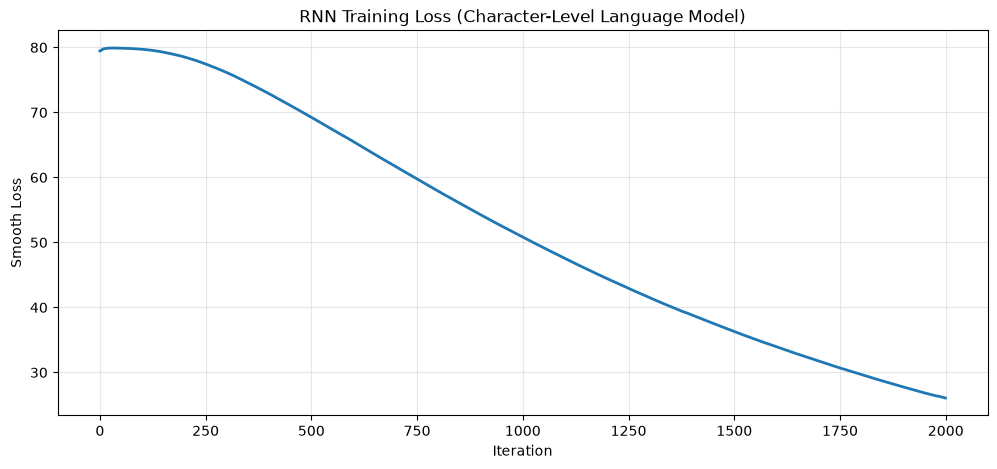

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Smooth Loss')
plt.title('RNN Training Loss (Character-Level Language Model)')
plt.grid(True, alpha=0.3)
plt.show()

## Generate Text from Trained Model(用训练好的模型生成文本)

#### 💻 代码解读

**做什么:** 用训练好的模型自由"写作"——从 5 个随机起始字符出发,各生成一段 150 字符的文本。

**怎么做:**
- 先把隐藏状态 `h` 清零(让模型从"空白记忆"开始)。
- 循环 5 次:每次用 `np.random.choice(chars)` 随机挑一个种子字符 `seed_char`,查 `char_to_ix` 得到它的编号。
- 调用 `rnn.sample(h, seed_ix, 150)` 生成 150 个字符的编号序列,再用 `ix_to_char` 翻译回文字。
- 打印每个样本,可以观察到模型虽然只学过"猜下一个字符",却能拼出训练文本里的单词和短语。

In [6]:
# Generate samples with different seeds
# 生成时从全零隐藏态出发,只给一个种子字符,让模型自回归续写
h = np.zeros((hidden_size, 1))

print("Generated samples:\n")
for i in range(5):
    seed_char = np.random.choice(chars)
    seed_ix = char_to_ix[seed_char]
    sample_ix = rnn.sample(h, seed_ix, 150)
    # 生成器表达式把索引序列译回字符并拼成字符串
    txt = ''.join(ix_to_char[ix] for ix in sample_ix)
    print(f"Sample {i+1} (seed: '{seed_char}'):")
    print(txt)
    print()

Generated samples:

Sample 1 (seed: 'n'):
g
deatlormation in foro weves
neu eles eveura
dppleusslearn ing
datern learn garn prn dea data 
eve
woverning
tero deep networks prompllog 
oete
data 

Sample 2 (seed: 'h'):
ero
datarng leorywherllerng
nerp les networks
foru illhneworydseterns in datp
data heoel networks prorning
nearn is pvarywhero dxacess ing fouton lear

Sample 3 (seed: 'h'):
ellorn plo dep networks
erna
leuralveura datp data n ation ion foa llo
datetywherhworn deatlon llo world
heep nearn in inins
patterns
infork
pexaces p

Sample 4 (seed: 'v'):
ern ing ferlo
s eatterywors pxemplxarn deea in llnerning footlo wformples exaves everwoorng dello
deuules patterns
patp
heevern
learn patterns patlo w

Sample 5 (seed: 'x'):
ameueverywheredfrom eleerng
data
here york
you loom leveces is
examples heles
leurloces iivetwo data drocexarywheres look data dateo
deatos plo yerywn



## Visualize Hidden State Activations(可视化隐藏状态激活)

#### 💻 代码解读

**做什么:** 给模型输入一句测试文本 "hello deep learning",把它内部 64 个隐藏单元的激活值画成热力图,直观看看 RNN 的"脑内活动"。

**怎么做:**
- 把 `test_text` 逐字符转成编号 `test_inputs`,以全零隐藏状态调用 `rnn.forward`,拿到每个时间步的隐藏状态 `hs`。
- 把各时间步的隐藏状态拼成矩阵 `hidden_states`(每行对应一个字符位置,每列对应一个隐藏单元)。
- 用 `plt.imshow` 画热力图:横轴是字符位置(刻度直接标出每个字母),纵轴是 64 个隐藏单元,红蓝深浅表示激活值的正负与大小——好比给大脑做"扫描成像",能看到不同神经元在读到不同字符时被点亮或抑制。

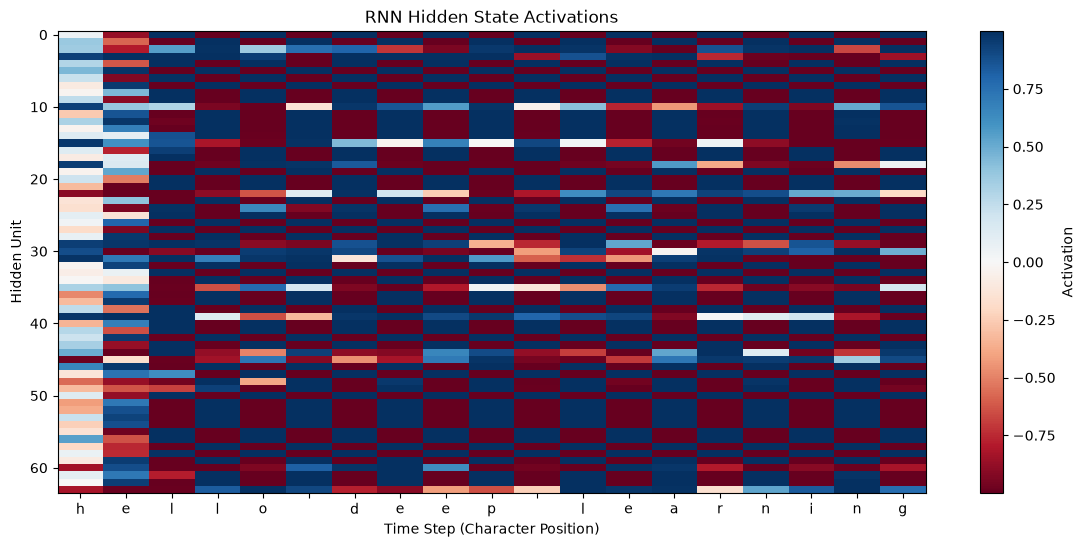


Visualization shows how hidden states evolve as RNN processes 'hello deep learning'


In [7]:
# Forward pass through a sequence to visualize activations
test_text = "hello deep learning"
test_inputs = [char_to_ix[ch] for ch in test_text]
hprev = np.zeros((hidden_size, 1))

xs, hs, ys, ps = rnn.forward(test_inputs, hprev)

# Extract hidden states
# 把每个时间步的(hidden_size,1)隐藏态展平后堆叠,形状:(seq_len, hidden_size)
hidden_states = np.array([hs[t].flatten() for t in range(len(test_inputs))])

plt.figure(figsize=(14, 6))
# 转置成(hidden_size, seq_len)画热力图:横轴时间步,纵轴各隐藏单元的激活值
plt.imshow(hidden_states.T, cmap='RdBu', aspect='auto', interpolation='nearest')
plt.colorbar(label='Activation')
plt.xlabel('Time Step (Character Position)')
plt.ylabel('Hidden Unit')
plt.title('RNN Hidden State Activations')
plt.xticks(range(len(test_text)), list(test_text))
plt.show()

print(f"\nVisualization shows how hidden states evolve as RNN processes '{test_text}'")

## Key Takeaways(核心要点)

1. **Character-Level Modeling**: RNNs can learn to generate text character-by-character
2. **Recurrent Connections**: Hidden state carries information across time steps
3. **Backpropagation Through Time**: Gradients flow backwards through sequences
4. **Gradient Clipping**: Essential to prevent exploding gradients
5. **Sampling**: Temperature control in sampling affects diversity

1. **字符级建模(Character-Level Modeling)**:RNN 可以学会逐字符地生成文本
2. **循环连接(Recurrent Connections)**:隐藏状态(hidden state)在时间步之间传递信息
3. **随时间反向传播(Backpropagation Through Time)**:梯度沿序列反向流动
4. **梯度裁剪(Gradient Clipping)**:防止梯度爆炸(exploding gradients)的关键手段
5. **采样(Sampling)**:采样时的温度(temperature)控制会影响生成的多样性

### The Unreasonable Effectiveness:(不可思议的有效性:)
- Simple RNN architecture can learn complex patterns
- No explicit feature engineering needed
- Learns hierarchical representations automatically
- Generalizes to unseen character combinations

- 简单的 RNN 架构就能学习复杂模式
- 无需显式的特征工程(feature engineering)
- 自动学习层次化表示(hierarchical representations)
- 能泛化到未见过的字符组合